In [10]:
import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.signal import butter, filtfilt, windows
import matplotlib.pyplot as plt

In [14]:
# Load EMG signal (replace with your file)
emg = pd.read_csv(r"C:\Users\rdong\OneDrive\Desktop\Trial_8 - Copy.csv", skiprows=1)
time=emg.iloc[:, 0].values
emg_muscle=emg.iloc[:,1].values
#or
# data = np.loadtxt(r"C:\Users\DELL\Downloads\Trial_8 - Copy.csv", delimiter=",", skiprows=8)
# t=data[:, 0]
# Emg=data[:, 1]
# Sampling frequency (Hz) — CHANGE THIS
fs = 2148









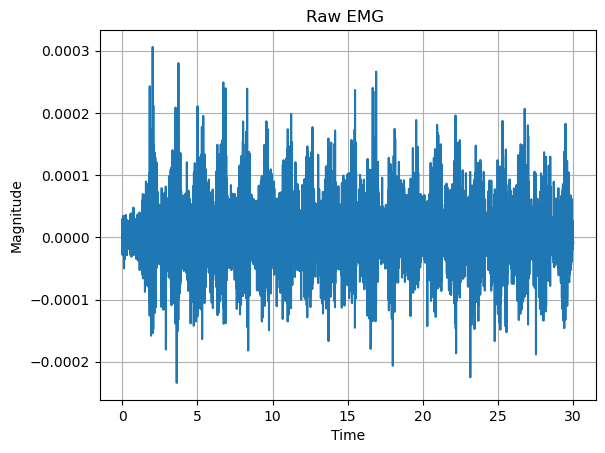

In [15]:
plt.figure()
plt.plot(time,emg_muscle)
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.title("Raw EMG ")
plt.grid()
plt.show()

In [16]:
#FFT
fft_values = np.fft.fft(emg_muscle)
#Freq Axis
N = len(emg_muscle)
freqs = np.fft.fftfreq(N, d=1/fs)

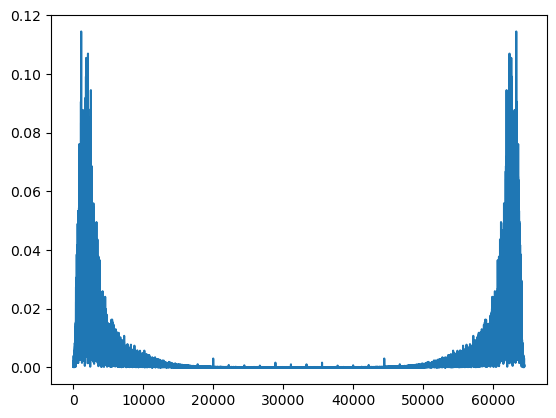

In [17]:
#Magnitude Spectrum; ignoring the phase
mag = np.abs(fft_values)
plt.plot(mag)

In [18]:
half = N // 2

freqs_half = freqs[:half]
mag_half = mag[:half]
magnitude = (np.abs(mag_half))/ N
# magnitude=mag[:half]/N
# plt.plot(magnitude)
# plt.plot(magnitude[1:])
magnitude[1:] = 2 * magnitude[1:]
# plt.plot(magnitude)

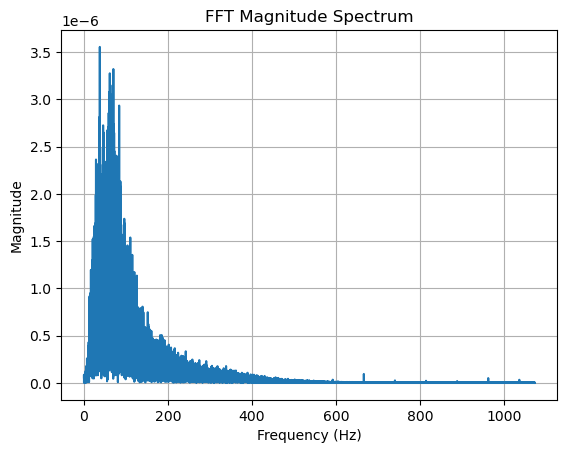

In [19]:
plt.figure()
plt.plot(freqs_half, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Magnitude Spectrum")
plt.grid()
plt.show()

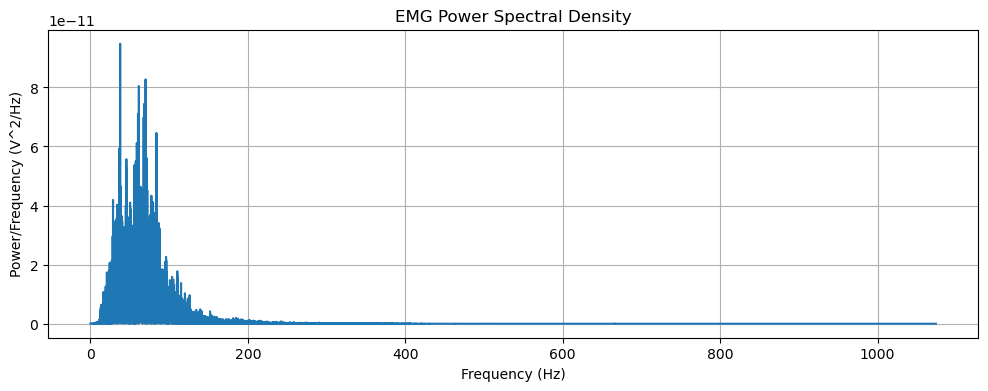

In [20]:
psd = (1/(fs*N)) * np.abs(fft_values[:half])**2


plt.figure(figsize=(12,4))
plt.plot(freqs_half, psd) 
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (V^2/Hz)")
plt.title("EMG Power Spectral Density")
plt.grid()
plt.show()

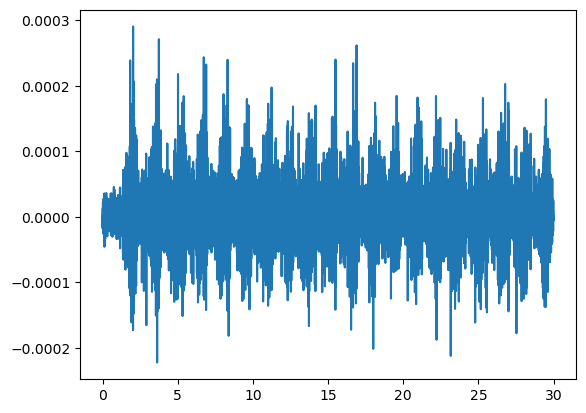

In [21]:
def bandpass_filter(signal, fs, lowcut=20, highcut=450, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered

emg_filtered = bandpass_filter(emg_muscle, fs)
plt.plot(time,emg_filtered)

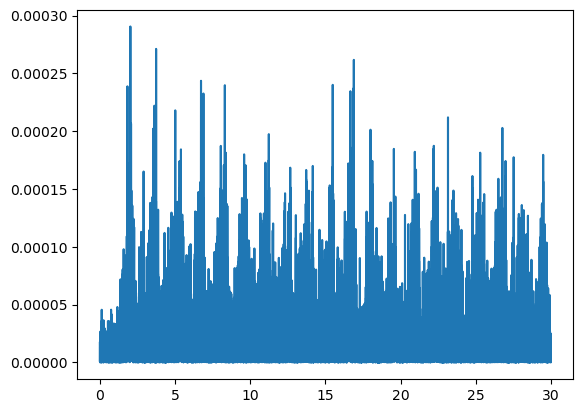

In [22]:
#Rectification
emg_rectified = np.abs(emg_filtered)
plt.plot(time, emg_rectified)

In [23]:
def rms_envelope(signal, fs, window_ms=50):
    window_size = int(fs * window_ms / 1000)
    squared = signal**2
    window = np.ones(window_size) / window_size
    rms = np.sqrt(np.convolve(squared, window, mode='same'))
    return rms

emg_env = rms_envelope(emg_rectified, fs, window_ms=50)

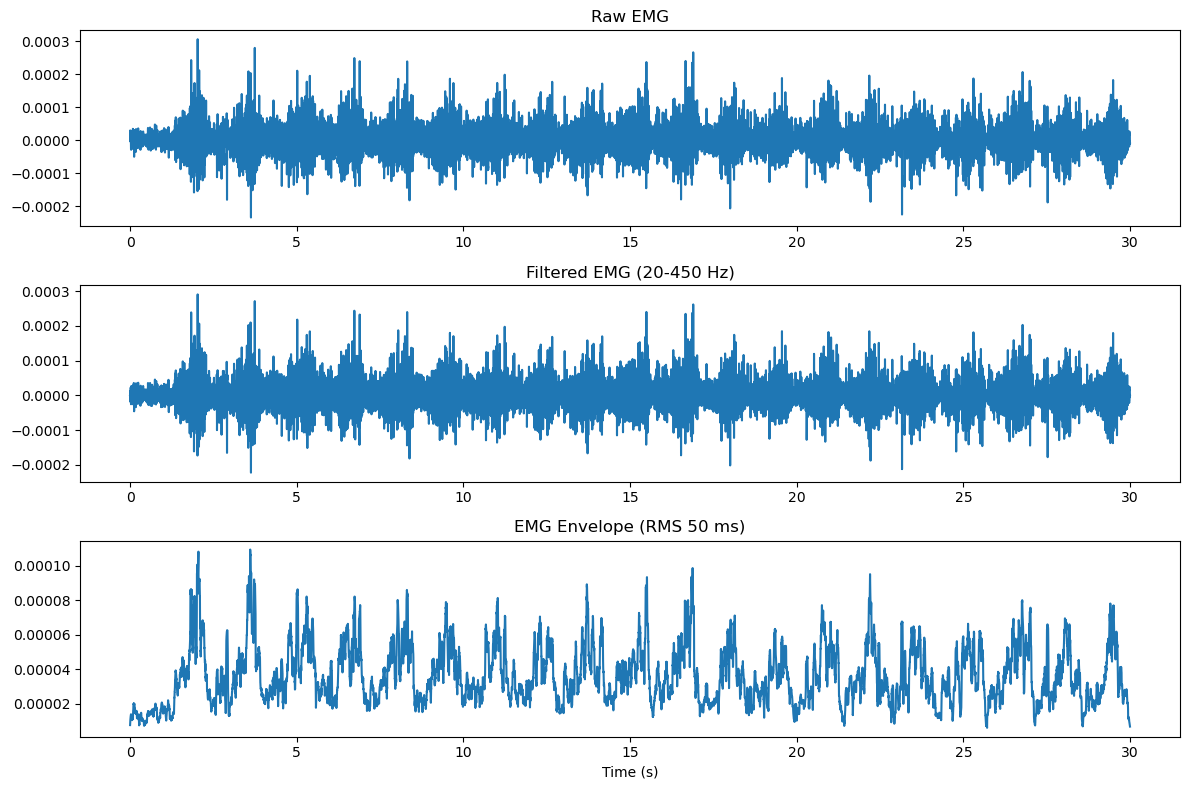

In [24]:
plt.figure(figsize=(12, 8))

plt.subplot(3,1,1)
plt.plot(time, emg_muscle)
plt.title("Raw EMG")

plt.subplot(3,1,2)
plt.plot(time, emg_filtered)
plt.title("Filtered EMG (20-450 Hz)")

plt.subplot(3,1,3)
plt.plot(time, emg_env)
plt.title("EMG Envelope (RMS 50 ms)")
plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [25]:
def lowpass_envelope(signal, fs, cutoff=10, order=4):
    """
    Low-pass filter the rectified EMG to get smooth envelope.
    cutoff: Hz (typical 5-20 Hz)
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    env = filtfilt(b, a, signal)
    return env
emg_env_smooth = lowpass_envelope(emg_rectified, fs, cutoff=10)

In [26]:
# 1. Mean Amplitude (Mean Absolute Value)
mean_amplitude = np.mean(np.abs(emg_muscle))
print(f"Mean Amplitude (MAV): {mean_amplitude:.4f}")

Mean Amplitude (MAV): 0.0000


In [27]:
# Use Welch's method to estimate power spectral density
from scipy.signal import welch
frequencies, power = welch(emg_muscle, fs=fs, nperseg=min(256, len(emg_muscle)))

# Mean Frequency (MNF) = sum(f * P(f)) / sum(P(f))
mean_frequency = np.sum(frequencies * power) / np.sum(power)
print(f"Mean Frequency (MNF): {mean_frequency:.2f} Hz")

Mean Frequency (MNF): 69.06 Hz
